# PREVISIONE POPOLARITÀ CANZONI

## Descrizione del problema

obiettivo

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## Caricamento dei dati
Questo dataset, ottenuto da Kaggle, contiene un insieme di brani Spotify, appartenenti a diversi generi musicali, corredati delle rispettive caratteristiche audio.

### Feature del Dataset
- `track_id`: Spotify ID del brano
- `artists`: artista o gruppo che esegue il brano
- `album_name`: nome dell’album in cui è contenuto il brano
- `track_name`: titolo della traccia
- `duration_ms`: durata del brano in millisecondi
- `explicit`: indica se il brano contiene contenuti espliciti (True/False)
- `danceability`: misura quanto il brano è "ballabile"
- `energy`: livello di intensità e di energia del brano
- `key`: tonalità musicale del brano (codificata numericamente: 0=C, 1=C#/Db, 2=D,...)
- `loudness`: volume medio del brano in decibel
- `mode`: modalità musicale (maggiore = 1, minore = 0)
- `speechiness`: presenza di parlato nel brano
- `acousticness`: probabilità che il brano sia acustico
- `instrumentalness`: probabilità che il brano sia strumentale (senza voce)
- `liveness`: probabilità che il brano sia registrato dal vivo
- `valence`: misura della positività/“felicità” del brano
- `tempo`: velocità del brano in BPM (battiti per minuto)
- `time_signature`: numero di battiti per misura (valori compresi tra 3 (3/4) e 7 (7/4))
- `track_genre`: genere musicale del brano

La variabile target da predirre è `popularity`, l'indice di popolarità del brano (di solito da 0 a 100)

In [2]:
import os.path
file = "dataset.csv";
if not os.path.exists(file):
    print("Missing dataset");

df = pd.read_csv(file, index_col=0);

In [3]:
df.info(verbose=False, memory_usage="deep");

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Columns: 20 entries, track_id to track_genre
dtypes: bool(1), float64(9), int64(5), str(5)
memory usage: 48.8 MB


In [4]:
df.head(1)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.143,0.0322,0.000001,0.358,0.715,87.917,4,acoustic


Si osserva che le colonne `artists`, `album_name` e `track_genre` possono essere categorizzate, per ottimizzare lo spazio in memoria.
Si procede quindi a ricaricare il DataFrame, eliminando anche le colonne `track_id` e `track_name`, non rilevanti rispetto all’obiettivo.

In [5]:
categorical = ["artists", "album_name", "track_genre"]
df = pd.read_csv(file, index_col=0, dtype={col: "category" for col in categorical})
df.info(verbose=False, memory_usage="deep")
df.drop(columns=["track_id", "track_name"], inplace=True);

df.head(1)
df.info(verbose=False, memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Columns: 20 entries, track_id to track_genre
dtypes: bool(1), category(3), float64(9), int64(5), str(2)
memory usage: 36.0 MB
<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Columns: 18 entries, artists to track_genre
dtypes: bool(1), category(3), float64(9), int64(5)
memory usage: 20.7 MB


Si può osservare come l’utilizzo di memoria risulti significativamente ridotto rispetto alla situazione iniziale.

## Analisi esplorativa dei dati
Si procede con la visualizzazione di alcune statistiche descrittive relative ai dati oggetto di analisi.

In [6]:
print("songs" + ":    \t" + str(len(df)))
for x in ["artists", "album_name", "track_genre"]:
    print(x + ":   \t"+ str(df[x].nunique()));

songs:    	114000
artists:   	31437
album_name:   	46589
track_genre:   	114


Il dataset contiene quindi informazioni relative a 114000 brani, 31437 artisti, 46589 album e 114 generi musicali.

In [7]:
def plot_bar(feature, n, title):
    values = df[feature].value_counts()[:n]
    colors = [f"#{np.random.randint(0, 0xFFFFFF):06x}" for _ in range(len(values))]
    ax = values.plot.bar(figsize=(15, 4), color=colors)
    ax.set_title(title)
    plt.show()

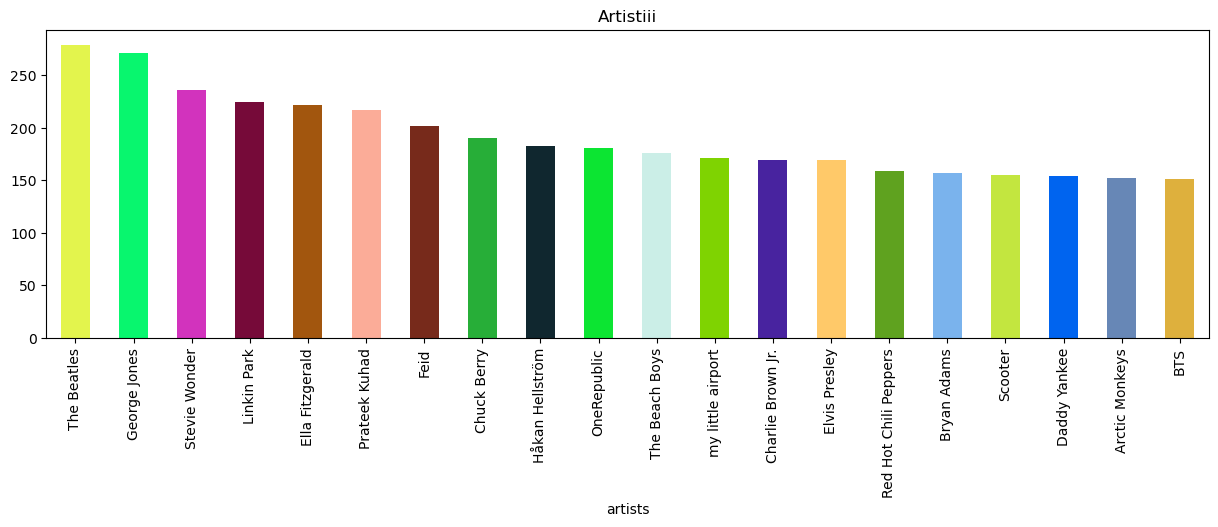

In [8]:
plot_bar("artists", 20, "Artistiii")

## Preparazione dei dati
testo preparazione

In [68]:
print('preparazione dati')

preparazione dati


## Preparazione del modello
testo modello

## Conclusioni
testo conclusione